<a href="https://colab.research.google.com/github/ShAnFb82/IAD1/blob/main/IADlab1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Завантажуємо датасет
df = pd.read_csv('drebin-215-dataset-5560malware-9476-benign.csv')

# Виводимо розмір датасета (кількість рядків та колонок)
print("Розмір датасета:", df.shape)

# Виводимо перші 5 рядків, щоб подивитися на дані
display(df.head())

# Дивимось, скільки у нас шкідливих і безпечних додатків
# У датасеті Drebin цільова колонка зазвичай називається 'class'
print("\nРозподіл за класами:")
print(df['class'].value_counts())

Розмір датасета: (15036, 216)


/tmp/ipykernel_1913/1174494011.py:7: DtypeWarning: Columns (92) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('drebin-215-dataset-5560malware-9476-benign.csv')


,transact,onServiceConnected,bindService,attachInterface,ServiceConnection,android.os.Binder,SEND_SMS,Ljava.lang.Class.getCanonicalName,Ljava.lang.Class.getMethods,Ljava.lang.Class.cast,...,READ_CONTACTS,DEVICE_POWER,HARDWARE_TEST,ACCESS_WIFI_STATE,WRITE_EXTERNAL_STORAGE,ACCESS_FINE_LOCATION,SET_WALLPAPER_HINTS,SET_PREFERRED_APPLICATIONS,WRITE_SECURE_SETTINGS,class
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,S
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,S
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,S
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,1,1,0,0,0,S
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,S



Розподіл за класами:
class
B    9476
S    5560
Name: count, dtype: int64


In [5]:
# 1. Кодування цільової змінної 'class' (категоріальна ознака)
# 'B' (Benign - безпечні) стає 0, 'S' (Malware - шкідливі) стає 1
df['class'] = df['class'].map({'B': 0, 'S': 1})

# 2. Виправлення типів даних та проблеми з 92-ю колонкою
# Примусово перетворюємо весь датасет у числа.
# Параметр errors='coerce' перетворить будь-яке текстове сміття у порожні значення (NaN)
df = df.apply(pd.to_numeric, errors='coerce')

# 3. Перевірка на наявність пропущених значень (NaN)
missing_values = df.isnull().sum().sum()
print(f"Кількість пропусків ДО обробки: {missing_values}")

if missing_values > 0:
    # Оскільки всі наші ознаки - це наявність або відсутність дозволів/API-викликів,
    # найбільш логічно заповнити невідомі значення нулями (тобто "дозволу немає")
    df = df.fillna(0)
    print("Всі пропуски успішно заповнено нулями.")

# 4. Визначаємо ознаки (X) та цільову змінну (y)
X = df.drop('class', axis=1) # Всі колонки, крім 'class'
y = df['class']              # Тільки колонка 'class'

print("\nРозмір матриці ознак (X):", X.shape)
print("Новий розподіл класів (0 - безпечні, 1 - шкідливі):")
print(y.value_counts())

Кількість пропусків ДО обробки: 5
Всі пропуски успішно заповнено нулями.

Розмір матриці ознак (X): (15036, 215)
Новий розподіл класів (0 - безпечні, 1 - шкідливі):
class
0    9476
1    5560
Name: count, dtype: int64


Топ-10 найважливіших ознак:
 ['SEND_SMS', 'android.telephony.SmsManager', 'READ_PHONE_STATE', 'RECEIVE_SMS', 'READ_SMS', 'android.intent.action.BOOT_COMPLETED', 'TelephonyManager.getLine1Number', 'WRITE_SMS', 'WRITE_HISTORY_BOOKMARKS', 'TelephonyManager.getSubscriberId']


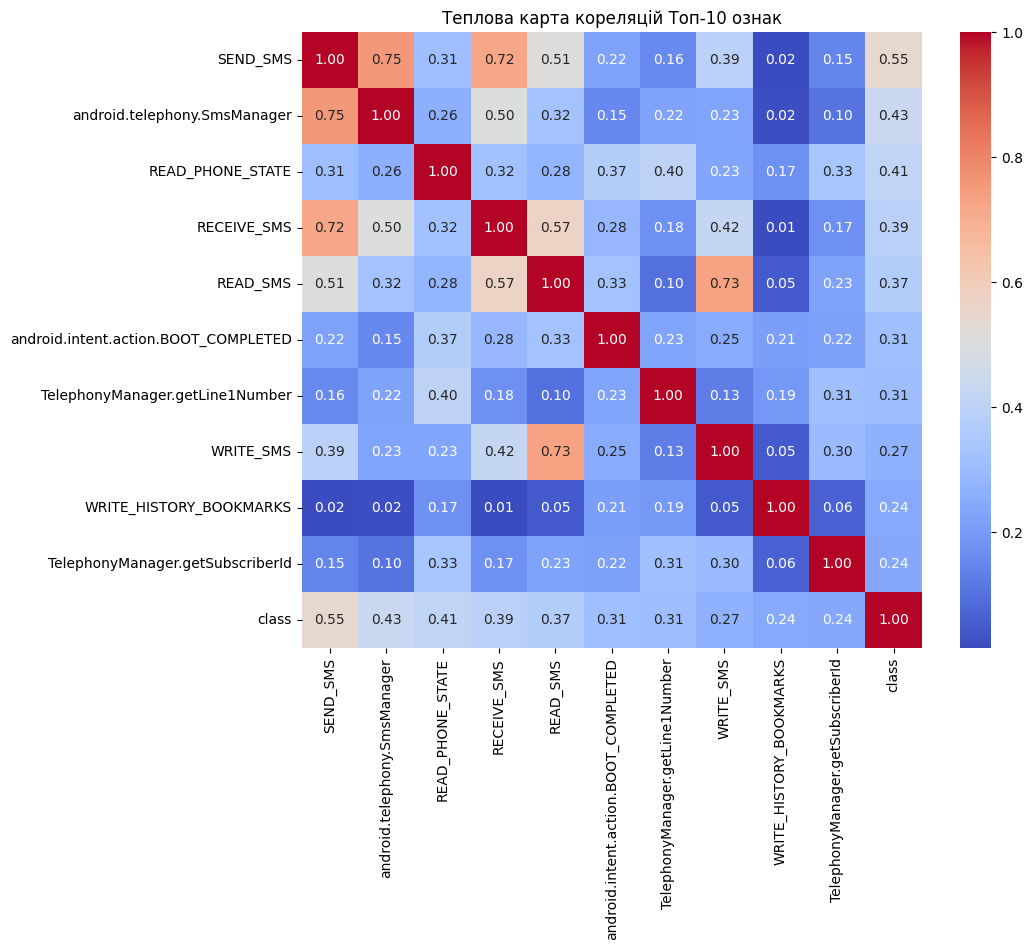

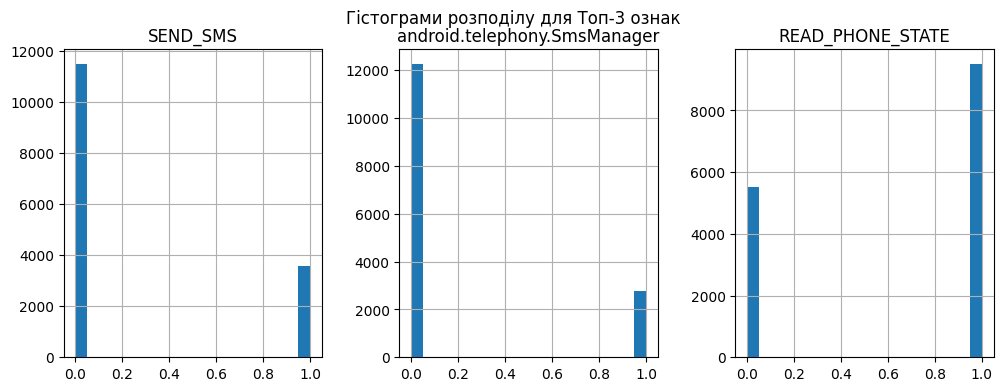

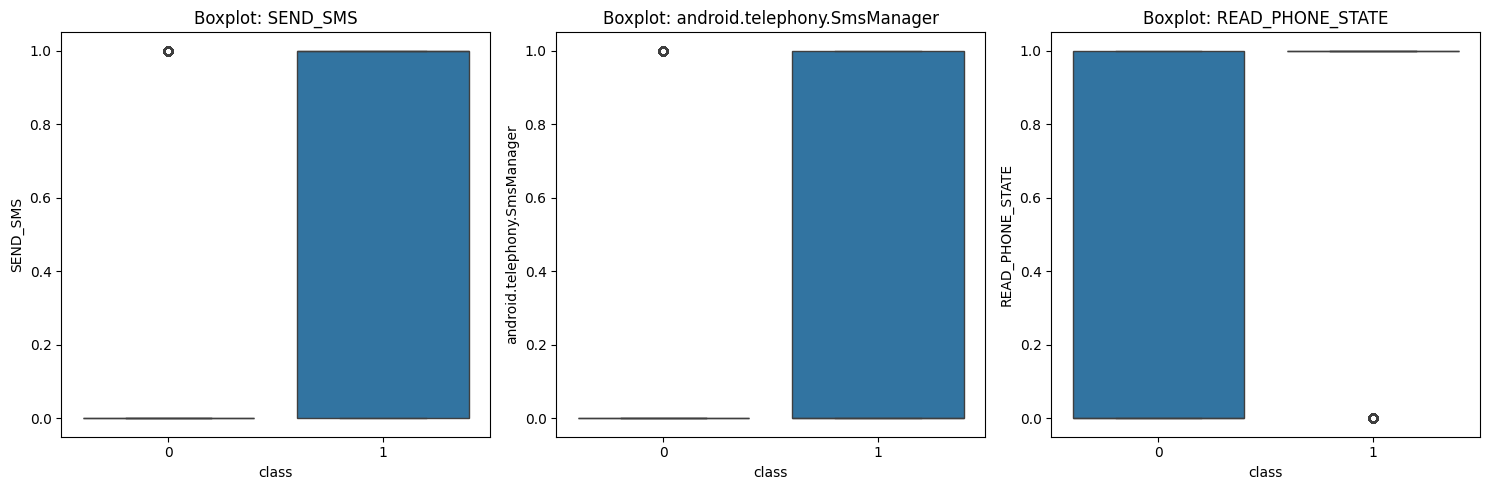

In [6]:
# Знаходимо кореляцію всіх ознак з цільовою змінною 'class'
correlations = df.corr()['class'].sort_values(ascending=False)

# Беремо топ-10 ознак (без самої колонки 'class')
top_features = correlations[1:11].index.tolist()
print("Топ-10 найважливіших ознак:\n", top_features)

# 1. Heatmap (Теплова карта кореляцій)
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features + ['class']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Теплова карта кореляцій Топ-10 ознак')
plt.show()

# 2. Гістограми розподілу для топ-3 ознак
df[top_features[:3]].hist(bins=20, figsize=(12, 4), layout=(1, 3))
plt.suptitle('Гістограми розподілу для Топ-3 ознак')
plt.show()

# 3. Boxplot-и (Ящики з вусами) для топ-3 ознак відносно класу
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, feature in enumerate(top_features[:3]):
    sns.boxplot(x='class', y=feature, data=df, ax=axes[i])
    axes[i].set_title(f'Boxplot: {feature}')
plt.tight_layout()
plt.show()